In [3]:
!pip install langchain langchain_core langchain_community langchain_openai langchain_text_splitters langchain-google-genai langgraph python-dotenv pypdf faiss-cpu transformers pydantic dotenv -q

## Sequential Workflow 

### BMI Workflow 

Let's start learning langGraph by making a small BMI Calc. Input -> Calc BMI -> Ouptut.

In [9]:
from langgraph.graph import StateGraph, START, END

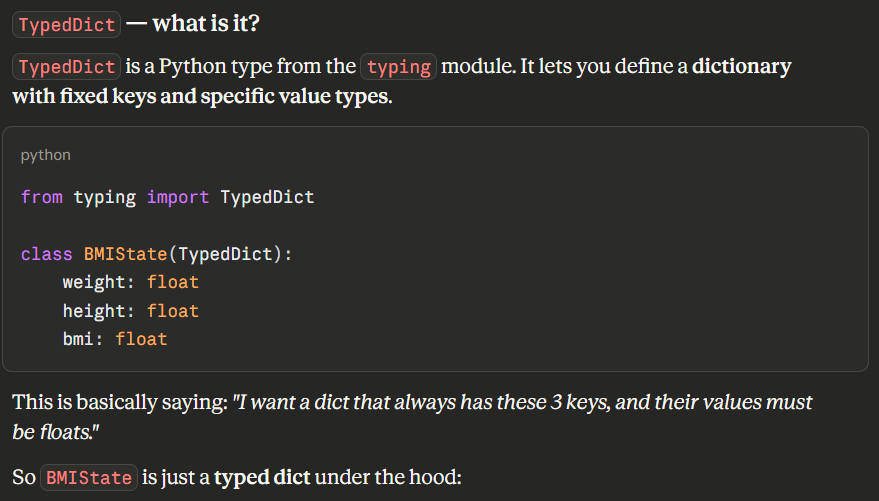
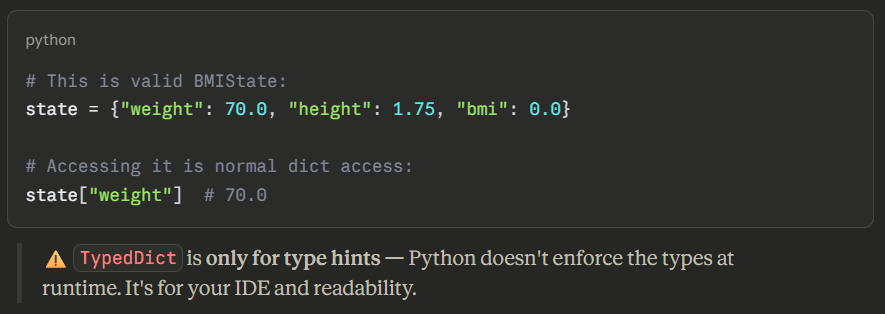

In [19]:
# step - 1 : Define the state of the graph
from typing import TypedDict

class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    overweight: str

# step - 2 : Create the graph
bmi_graph = StateGraph(BMIState)

def calculate_bmi(state: BMIState) -> BMIState:
    weight = state["weight"]
    height = state["height"]
    bmi = round(weight / (height ** 2), 2)

    state["bmi"] = bmi
    return state

def is_overweight(state: BMIState) -> BMIState:
    bmi = state["bmi"]
    state["overweight"] = "Yes" if bmi > 25 else "No"
    return state

# step - 3 : add nodes to the graph
bmi_graph.add_node("calculate_bmi", calculate_bmi)
bmi_graph.add_node("is_overweight", is_overweight)
                   

# step - 4 : add edges to the graph
bmi_graph.add_edge(START, "calculate_bmi")
bmi_graph.add_edge("calculate_bmi", "is_overweight")
bmi_graph.add_edge("is_overweight", END)

# step - 5 : compile the graph
workflow = bmi_graph.compile()

# step - 6 : invoke the graph with an initial state
initial_state = {
    "weight": 70,  # in kg  
    "height": 1.75  # in meters
}

output_state = workflow.invoke(initial_state)
output_state

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'overweight': 'No'}

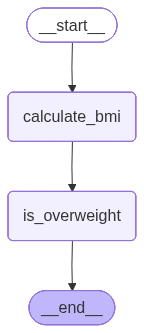

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### LLM Based workflow

In [31]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv

# initialize the model and load environment variables
load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    temperature=1.0,  
    max_tokens=None,
    timeout=None 
)

In [32]:
# create a state

class ChatState(TypedDict):
    question:str
    ans:str

# create a graph
llm_graph = StateGraph(ChatState)

# create node functions
def llm_question(state: ChatState) -> ChatState:
    question = state["question"]
    prompt = f'Answer the following question: {question}'
    answer = model.invoke(prompt).content
    state["ans"] = answer
    return state
   
# add nodes to the graph
llm_graph.add_node("llm_question", llm_question)

# add edges to the graph
llm_graph.add_edge(START, "llm_question")
llm_graph.add_edge("llm_question", END)

# compile the graph
llm_workflow = llm_graph.compile()

# invoke the graph with an initial state
initial_chat_state = {
    "question": "What is the capital of France?"
}
output_chat_state = llm_workflow.invoke(initial_chat_state)
output_chat_state

{'question': 'What is the capital of France?',
 'ans': 'The capital of France is **Paris**.'}

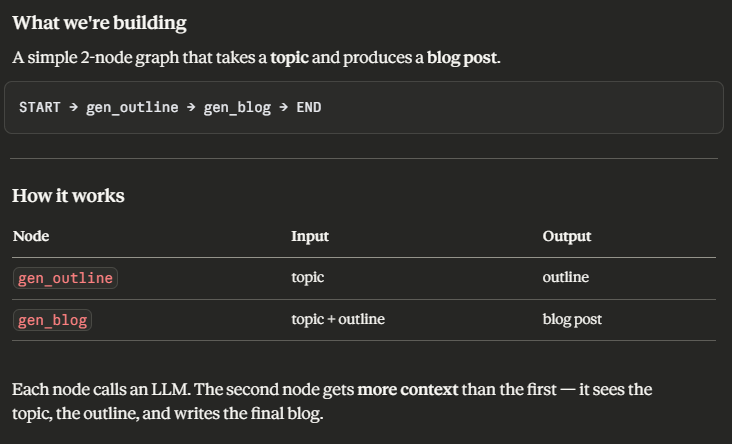

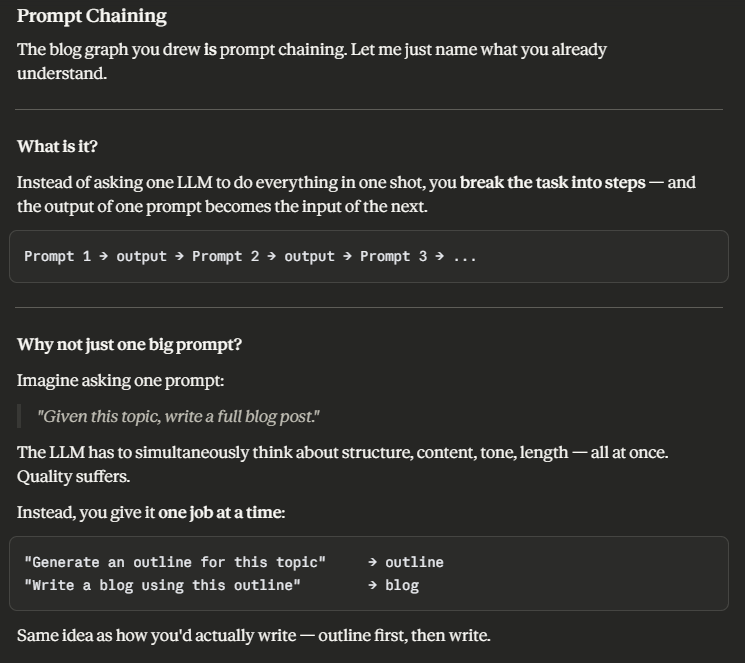

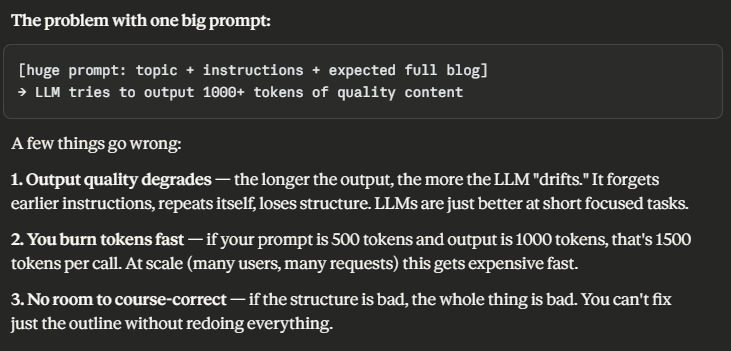

In [33]:
# define state

class chatState(TypedDict):
    topic: str
    outline: str
    answer: str

# graph 
chat_graph = StateGraph(chatState)

def generate_outline(state: chatState) -> chatState:
    topic = state["topic"]
    prompt = f'Generate a detailed outline to write an essay on the topic: {topic}'
    outline = model.invoke(prompt).content
    state["outline"] = outline
    return state

def generate_content(state: chatState) -> chatState:
    outline = state["outline"]
    prompt = f'Write a detailed essay based on the following outline: {outline}'
    answer = model.invoke(prompt).content
    state["answer"] = answer
    return state

# nodes
chat_graph.add_node("generate_outline", generate_outline)
chat_graph.add_node("generate_content", generate_content)

# edges
chat_graph.add_edge(START, "generate_outline")
chat_graph.add_edge("generate_outline", "generate_content")
chat_graph.add_edge("generate_content", END)

# workflow 
chat_workflow = chat_graph.compile()

# invoke the graph
initial_chat_state = {
    "topic": "The impact of AGI"
}

output_chat_state = chat_workflow.invoke(initial_chat_state)
output_chat_state

{'topic': 'The impact of AGI',
 'outline': 'Here\'s a detailed outline for an essay on "The Impact of AGI," designed to cover a comprehensive range of issues, from optimistic future scenarios to existential risks.\n\n---\n\n## Essay Outline: The Impact of Artificial General Intelligence (AGI)\n\n**Essay Title Idea:** The Dawn of a New Epoch: Navigating the Profound and Perilous Impacts of Artificial General Intelligence\n\n---\n\n### I. Introduction\n\n*   **A. Hook:** Start with a compelling statement about humanity\'s technological trajectory and the impending arrival of AGI as the ultimate innovation. (e.g., "From the wheel to the internet, human history is a testament to our capacity for invention, but none will rival the transformative power of Artificial General Intelligence.")\n*   **B. Define AGI (Briefly):** Differentiate AGI from current Artificial Narrow Intelligence (ANI). Explain AGI as a hypothetical intelligence capable of understanding, learning, and applying its intell

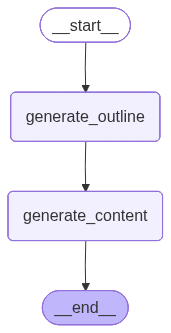

In [34]:
from IPython.display import Image
Image(chat_workflow.get_graph().draw_mermaid_png())

In [37]:
print(output_chat_state['outline'])

Here's a detailed outline for an essay on "The Impact of AGI," designed to cover a comprehensive range of issues, from optimistic future scenarios to existential risks.

---

## Essay Outline: The Impact of Artificial General Intelligence (AGI)

**Essay Title Idea:** The Dawn of a New Epoch: Navigating the Profound and Perilous Impacts of Artificial General Intelligence

---

### I. Introduction

*   **A. Hook:** Start with a compelling statement about humanity's technological trajectory and the impending arrival of AGI as the ultimate innovation. (e.g., "From the wheel to the internet, human history is a testament to our capacity for invention, but none will rival the transformative power of Artificial General Intelligence.")
*   **B. Define AGI (Briefly):** Differentiate AGI from current Artificial Narrow Intelligence (ANI). Explain AGI as a hypothetical intelligence capable of understanding, learning, and applying its intelligence to *any* intellectual task that a human being can pe

In [39]:
print(output_chat_state['answer'])

## The Dawn of a New Epoch: Navigating the Profound and Perilous Impacts of Artificial General Intelligence

From the earliest chipped flint tools to the marvels of the internet, human history is a testament to our insatiable capacity for innovation. Each epoch-defining invention has reshaped our existence, but none promise to rival the transformative power of Artificial General Intelligence (AGI). Unlike the specialized tools we currently employ, AGI represents a hypothetical intelligence capable of understanding, learning, and applying its intellect to *any* intellectual task that a human being can perform, exhibiting reasoning, problem-solving, creativity, and adaptability across diverse domains. As such, AGI represents an unprecedented turning point for humanity, capable of profoundly reshaping every facet of human existence, presenting both unparalleled opportunities for advancement and existential challenges that demand immediate and deliberate consideration.

To comprehend its p